# 大人数の顔認識

授業でも多くの人の顔を認識したがそれよりもっと多いのはどうだろう？
授業で62人という多い人数がいたがもっと多い人でも行けるのか気になったのでやってみましょう。

In [ ]:
%pip install ultralytics dill opencv-python matplotlib facenet-pytorch mtcnn

## ファイルの読み込み

ファイルを読み込むことに成功しましたね
次は読み込んだ画像の顔を認識してみましょう

## 画像の選定

人数の多い画像と言われて私は真っ先にこれが思いつきました。

In [ ]:
import cv2
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 画像とモデルの準備
image_path = Path("wally.jpg")
model_path = Path("yolov8m-face.pt")

# YOLO で高解像度推論（imgsz を指定）
model = YOLO(model_path)
result = model.predict(source=str(image_path), conf=0.25, verbose=False, imgsz=1280)[0]

# 画像読み込みと基本情報
annotated = cv2.imread(str(image_path))
h_img, w_img = annotated.shape[:2]
color = (0,255,0)
font_scale = 2
thickness = 2

# 検出結果を描画（バッファ付き）
for idx, box in enumerate(result.boxes.xyxy.cpu().numpy()):
    x1,y1,x2,y2 = map(int, box)
    w = x2 - x1; h = y2 - y1
    pad = int(max(w,h) * 0.2)  # バッファ 20%
    x1p = max(0, x1 - pad); y1p = max(0, y1 - pad)
    x2p = min(w_img, x2 + pad); y2p = min(h_img, y2 + pad)
    cv2.rectangle(annotated, (x1p,y1p), (x2p,y2p), color, thickness)
    label = f"ID:{idx}"
    (w_label, h_label), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
    y_label = y1p-6 if y1p-6>h_label else y1p+h_label+6
    cv2.rectangle(annotated, (x1p, y_label-h_label-baseline), (x1p+w_label, y_label+baseline), color, -1)
    cv2.putText(annotated, label, (x1p, y_label-baseline), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0,0,0), thickness, cv2.LINE_AA)

# 高解像度で保存（アップスケールして保存）
output_path = Path("wolly_yolo_faces.jpg")
annot_up = cv2.resize(annotated, (w_img*2, h_img*2), interpolation=cv2.INTER_CUBIC)
cv2.imwrite(str(output_path), annot_up)
print(f"検出された顔の数: {len(result.boxes)} faces")
plt.figure(figsize=(16,16))
plt.imshow(cv2.cvtColor(annot_up, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'wolly YOLO face × {len(result.boxes)} ')
plt.show()

おや？読み込めませんでしたね。
ではもっと数の少ないものをやってみましょう。

検出された顔の数: 28 faces


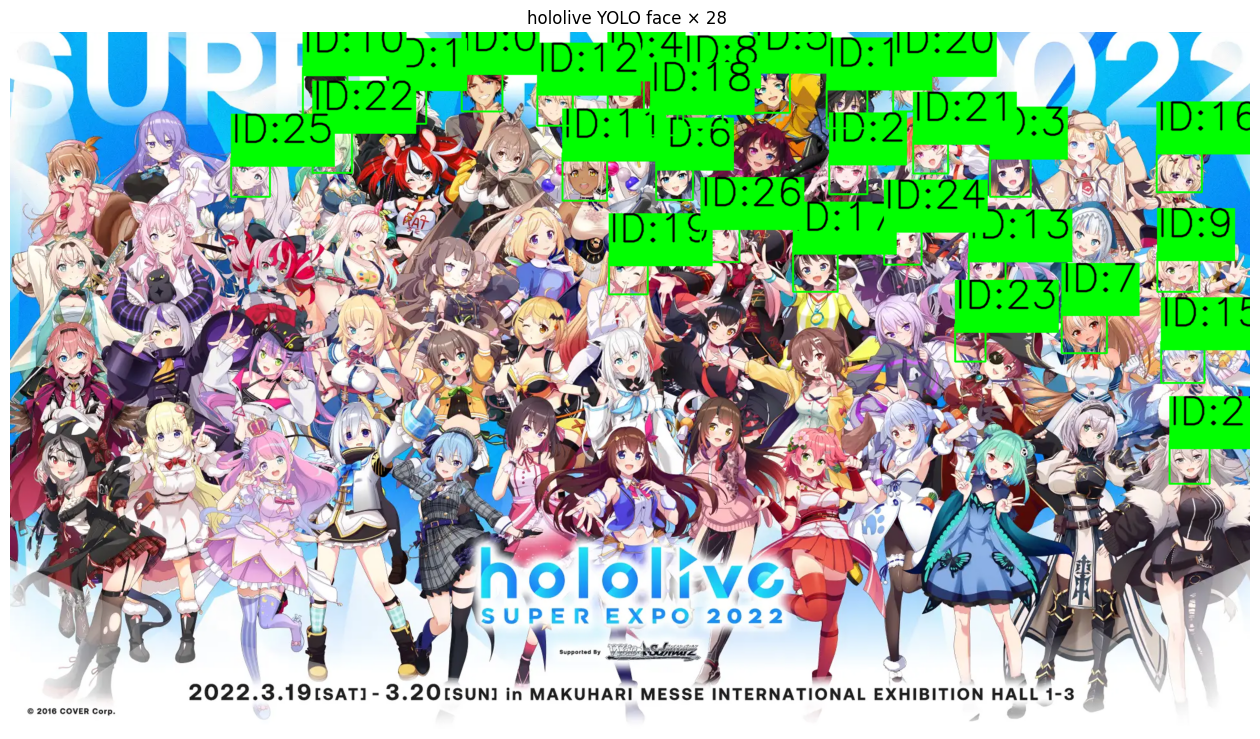

In [6]:
import cv2
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 画像とモデルの準備
image_path = Path("hololive2.jpg")
model_path = Path("yolov8m-face.pt")

# YOLO で高解像度推論（imgsz を指定）
model = YOLO(model_path)
result = model.predict(source=str(image_path), conf=0.25, verbose=False, imgsz=1280)[0]

# 画像読み込みと基本情報
annotated = cv2.imread(str(image_path))
h_img, w_img = annotated.shape[:2]
color = (0,255,0)
font_scale = 2
thickness = 2

# 検出結果を描画（バッファ付き）
for idx, box in enumerate(result.boxes.xyxy.cpu().numpy()):
    x1,y1,x2,y2 = map(int, box)
    w = x2 - x1; h = y2 - y1
    pad = int(max(w,h) * 0.2)  # バッファ 20%
    x1p = max(0, x1 - pad); y1p = max(0, y1 - pad)
    x2p = min(w_img, x2 + pad); y2p = min(h_img, y2 + pad)
    cv2.rectangle(annotated, (x1p,y1p), (x2p,y2p), color, thickness)
    label = f"ID:{idx}"
    (w_label, h_label), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
    y_label = y1p-6 if y1p-6>h_label else y1p+h_label+6
    cv2.rectangle(annotated, (x1p, y_label-h_label-baseline), (x1p+w_label, y_label+baseline), color, -1)
    cv2.putText(annotated, label, (x1p, y_label-baseline), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0,0,0), thickness, cv2.LINE_AA)

# 高解像度で保存（アップスケールして保存）
output_path = Path("hololive_yolo_faces.jpg")
annot_up = cv2.resize(annotated, (w_img*2, h_img*2), interpolation=cv2.INTER_CUBIC)
cv2.imwrite(str(output_path), annot_up)
print(f"検出された顔の数: {len(result.boxes)} faces")
plt.figure(figsize=(16,16))
plt.imshow(cv2.cvtColor(annot_up, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'hololive YOLO face × {len(result.boxes)} ')
plt.show()

顔を認識しましたがうまく全員を認識しませんでしたね。
もう一個画像があるのでそちらでもやってみましょう。

検出された顔の数: 10 faces


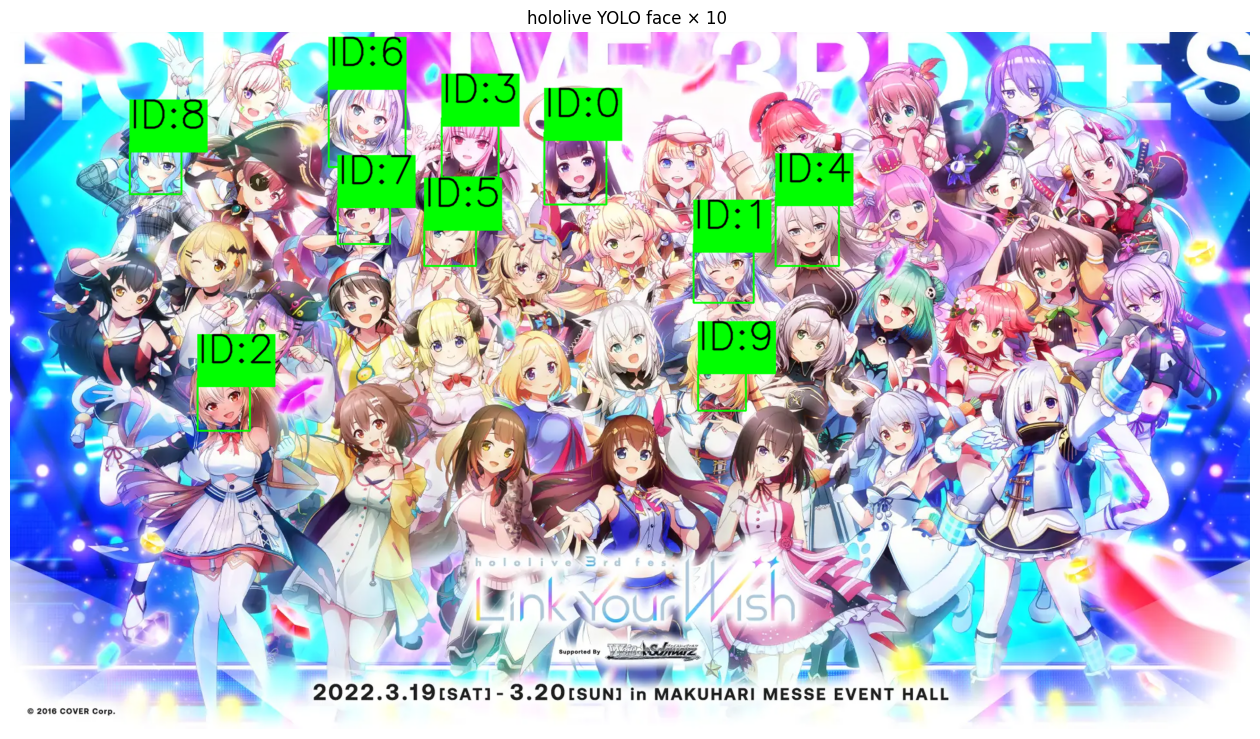

In [7]:
import cv2
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 画像とモデルの準備
image_path = Path("hololive.jpg")
model_path = Path("yolov8m-face.pt")

# YOLO で高解像度推論（imgsz を指定）
model = YOLO(model_path)
result = model.predict(source=str(image_path), conf=0.25, verbose=False, imgsz=1280)[0]

# 画像読み込みと基本情報
annotated = cv2.imread(str(image_path))
h_img, w_img = annotated.shape[:2]
color = (0,255,0)
font_scale = 2
thickness = 2

# 検出結果を描画（バッファ付き）
for idx, box in enumerate(result.boxes.xyxy.cpu().numpy()):
    x1,y1,x2,y2 = map(int, box)
    w = x2 - x1; h = y2 - y1
    pad = int(max(w,h) * 0.2)  # バッファ 20%
    x1p = max(0, x1 - pad); y1p = max(0, y1 - pad)
    x2p = min(w_img, x2 + pad); y2p = min(h_img, y2 + pad)
    cv2.rectangle(annotated, (x1p,y1p), (x2p,y2p), color, thickness)
    label = f"ID:{idx}"
    (w_label, h_label), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
    y_label = y1p-6 if y1p-6>h_label else y1p+h_label+6
    cv2.rectangle(annotated, (x1p, y_label-h_label-baseline), (x1p+w_label, y_label+baseline), color, -1)
    cv2.putText(annotated, label, (x1p, y_label-baseline), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0,0,0), thickness, cv2.LINE_AA)

# 高解像度で保存（アップスケールして保存）
output_path = Path("hololive2_yolo_faces.jpg")
annot_up = cv2.resize(annotated, (w_img*2, h_img*2), interpolation=cv2.INTER_CUBIC)
cv2.imwrite(str(output_path), annot_up)
print(f"検出された顔の数: {len(result.boxes)} faces")
plt.figure(figsize=(16,16))
plt.imshow(cv2.cvtColor(annot_up, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'hololive YOLO face × {len(result.boxes)} ')
plt.show()

もっとうまくいかなくなってしまいましたね。
そしたら大人数で乗っても大丈夫なあの画像でやってみましょう。

In [ ]:
import cv2
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 画像とモデルの準備
image_path = Path("inaba01.jpg")
model_path = Path("yolov8m-face.pt")

# YOLO で高解像度推論（imgsz を指定）
model = YOLO(model_path)
result = model.predict(source=str(image_path), conf=0.25, verbose=False, imgsz=1280)[0]

# 画像読み込みと基本情報
annotated = cv2.imread(str(image_path))
h_img, w_img = annotated.shape[:2]
color = (0,255,0)
font_scale = 2
thickness = 2

# 検出結果を描画（バッファ付き）
for idx, box in enumerate(result.boxes.xyxy.cpu().numpy()):
    x1,y1,x2,y2 = map(int, box)
    w = x2 - x1; h = y2 - y1
    pad = int(max(w,h) * 0.2)  # バッファ 20%
    x1p = max(0, x1 - pad); y1p = max(0, y1 - pad)
    x2p = min(w_img, x2 + pad); y2p = min(h_img, y2 + pad)
    cv2.rectangle(annotated, (x1p,y1p), (x2p,y2p), color, thickness)
    label = f"ID:{idx}"
    (w_label, h_label), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
    y_label = y1p-6 if y1p-6>h_label else y1p+h_label+6
    cv2.rectangle(annotated, (x1p, y_label-h_label-baseline), (x1p+w_label, y_label+baseline), color, -1)
    cv2.putText(annotated, label, (x1p, y_label-baseline), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0,0,0), thickness, cv2.LINE_AA)

# 高解像度で保存（アップスケールして保存）
output_path = Path("inaba_yolo_faces.jpg")
annot_up = cv2.resize(annotated, (w_img*2, h_img*2), interpolation=cv2.INTER_CUBIC)
cv2.imwrite(str(output_path), annot_up)
print(f"検出された顔の数: {len(result.boxes)} faces")
plt.figure(figsize=(16,16))
plt.imshow(cv2.cvtColor(annot_up, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'inaba YOLO face × {len(result.boxes)} ')
plt.show()

おお！認識できました。
認識できましたけど顔が見えないですね。
授業で使ったやつを利用してみましょう。

In [ ]:
# 切り出した顔のコラージュを高解像度で作成（関数化）：collage_faces(image_path) を定義・実行
import cv2
import numpy as np
from math import ceil
from pathlib import Path
import matplotlib.pyplot as plt

def collage_faces(image_path):
    """
    collage_faces(image_path): YOLO で検出して顔を切り出し、コラージュを作成する関数。
    引数は image_path のみ（文字列または Path）。
    """
    image_path = Path(image_path)
    model_path = Path('yolov8m-face.pt')
    from ultralytics import YOLO
    model = YOLO(model_path)
    result = model.predict(source=str(image_path), conf=0.25, verbose=False, imgsz=1280)[0]

    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f'Image not found: {image_path}')
    h_img, w_img = img.shape[:2]
    faces = []
    tile = 256

    for box in result.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        w = x2 - x1; h = y2 - y1
        pad = int(max(w, h) * 0.2)
        x1p = max(0, x1 - pad); y1p = max(0, y1 - pad)
        x2p = min(w_img, x2 + pad); y2p = min(h_img, y2 + pad)
        if x2p <= x1p or y2p <= y1p:
            continue
        crop = img[y1p:y2p, x1p:x2p]
        h_c, w_c = crop.shape[:2]
        size = max(h_c, w_c)
        square = np.full((size, size, 3), 255, dtype=np.uint8)
        y_off = (size - h_c)//2; x_off = (size - w_c)//2
        square[y_off:y_off+h_c, x_off:x_off+w_c] = crop
        faces.append(cv2.resize(square, (tile, tile), interpolation=cv2.INTER_AREA))

    if len(faces) == 0:
        print('コラージュ用の顔が見つかりません')
        return None

    cols = min(5, len(faces))
    rows = ceil(len(faces) / cols)
    canvas = np.full((rows*tile, cols*tile, 3), 255, dtype=np.uint8)
    for idx, f in enumerate(faces):
        r = idx // cols; c = idx % cols
        canvas[r*tile:(r+1)*tile, c*tile:(c+1)*tile] = f

    output_path = image_path.with_name(image_path.stem + '_faces_collage.jpg')
    cv2.imwrite(str(output_path), canvas)
    print(f'コラージュを保存しました: {output_path} (faces: {len(faces)})')
    plt.figure(figsize=(16,12))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'Faces collage ({len(faces)} faces)')
    plt.show()

# 関数を実行（reitaku.jpg を引数として渡す）
collage_faces('inaba01.jpg')

一人一人の顔が見やすくなりましたね。
イラストよりも人間のほうが認識しやすいのですかね？
もうちょっと試してみましょう！

In [ ]:
import cv2
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 画像とモデルの準備
image_path = Path("jitensya_papa_3nin_taihen.jpg")
model_path = Path("yolov8m-face.pt")

# YOLO で高解像度推論（imgsz を指定）
model = YOLO(model_path)
result = model.predict(source=str(image_path), conf=0.25, verbose=False, imgsz=1280)[0]

# 画像読み込みと基本情報
annotated = cv2.imread(str(image_path))
h_img, w_img = annotated.shape[:2]
color = (0,255,0)
font_scale = 2
thickness = 2

# 検出結果を描画（バッファ付き）
for idx, box in enumerate(result.boxes.xyxy.cpu().numpy()):
    x1,y1,x2,y2 = map(int, box)
    w = x2 - x1; h = y2 - y1
    pad = int(max(w,h) * 0.2)  # バッファ 20%
    x1p = max(0, x1 - pad); y1p = max(0, y1 - pad)
    x2p = min(w_img, x2 + pad); y2p = min(h_img, y2 + pad)
    cv2.rectangle(annotated, (x1p,y1p), (x2p,y2p), color, thickness)
    label = f"ID:{idx}"
    (w_label, h_label), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
    y_label = y1p-6 if y1p-6>h_label else y1p+h_label+6
    cv2.rectangle(annotated, (x1p, y_label-h_label-baseline), (x1p+w_label, y_label+baseline), color, -1)
    cv2.putText(annotated, label, (x1p, y_label-baseline), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0,0,0), thickness, cv2.LINE_AA)

# 高解像度で保存（アップスケールして保存）
output_path = Path("jitensya_yolo_faces.jpg")
annot_up = cv2.resize(annotated, (w_img*2, h_img*2), interpolation=cv2.INTER_CUBIC)
cv2.imwrite(str(output_path), annot_up)
print(f"検出された顔の数: {len(result.boxes)} faces")
plt.figure(figsize=(16,16))
plt.imshow(cv2.cvtColor(annot_up, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'jitensya YOLO face × {len(result.boxes)} ')
plt.show()

こんなに大きな顔でも認識しませんね。
ということはイラストを認識するのが難しいということがわかりましたね。
とても面白いことがわかりましたね。

In [ ]:
import cv2
import numpy as np
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

IMAGE_PATH = Path("wally.jpg")
MODEL_PATH = Path("yolov8m-face.pt")

CONF = 0.20          
IMG_SIZE = 1280
PAD_RATIO = 0.30     

def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    smooth = cv2.bilateralFilter(gray, 9, 75, 75)

    return cv2.cvtColor(smooth, cv2.COLOR_GRAY2BGR)

def main():
    raw = cv2.imread(str(IMAGE_PATH))
    if raw is None:
        raise FileNotFoundError("画像が読み込めません")

    h_img, w_img = raw.shape[:2]

    processed = preprocess(raw)

    model = YOLO(MODEL_PATH)
    result = model.predict(
        source=processed,
        conf=CONF,
        imgsz=IMG_SIZE,
        augment=True,
        verbose=False
    )[0]

    annotated = raw.copy()
    detections = []   

    for idx, box in enumerate(result.boxes.xyxy.cpu().numpy()):
        x1, y1, x2, y2 = map(int, box)
        w = x2 - x1
        h = y2 - y1

        pad = int(max(w, h) * PAD_RATIO)
        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)
        x2p = min(w_img, x2 + pad)
        y2p = min(h_img, y2 + pad)

        roi = raw[y1p:y2p, x1p:x2p]

        detections.append({
            "id": idx,
            "bbox": (x1p, y1p, x2p, y2p),
            "width": x2p - x1p,
            "height": y2p - y1p,
            "area_ratio": ((x2p - x1p) * (y2p - y1p)) / (w_img * h_img),
            "roi": roi
        })

        cv2.rectangle(annotated, (x1p, y1p), (x2p, y2p), (0,255,0), 2)
        cv2.putText(
            annotated,
            f"ID:{idx}",
            (x1p, y1p - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0,255,0),
            2,
            cv2.LINE_AA
        )

    faces_dir = Path("faces")
    faces_dir.mkdir(exist_ok=True)

    for d in detections:
        cv2.imwrite(
            str(faces_dir / f"face_{d['id']}.jpg"),
            d["roi"]
        )

    detections.sort(key=lambda x: x["area_ratio"], reverse=True)

    print(f"検出数: {len(detections)}")
    for d in detections[:5]:
        print(f"ID {d['id']} 面積比 {d['area_ratio']:.4f}")

    out = cv2.resize(
        annotated,
        (w_img * 2, h_img * 2),
        interpolation=cv2.INTER_CUBIC
    )

    cv2.imwrite("wolly_yolo_applied.jpg", out)

    plt.figure(figsize=(16, 16))
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Applied YOLO Face Detection × {len(detections)}")
    plt.show()

if __name__ == "__main__":
    main()


さっき認識しなかったウォーリーの画像を認識しましたね。
上手く面積比もできました。

検出数: 76
ID 5 面積比 0.0054
ID 38 面積比 0.0051
ID 74 面積比 0.0045
ID 49 面積比 0.0043
ID 72 面積比 0.0039


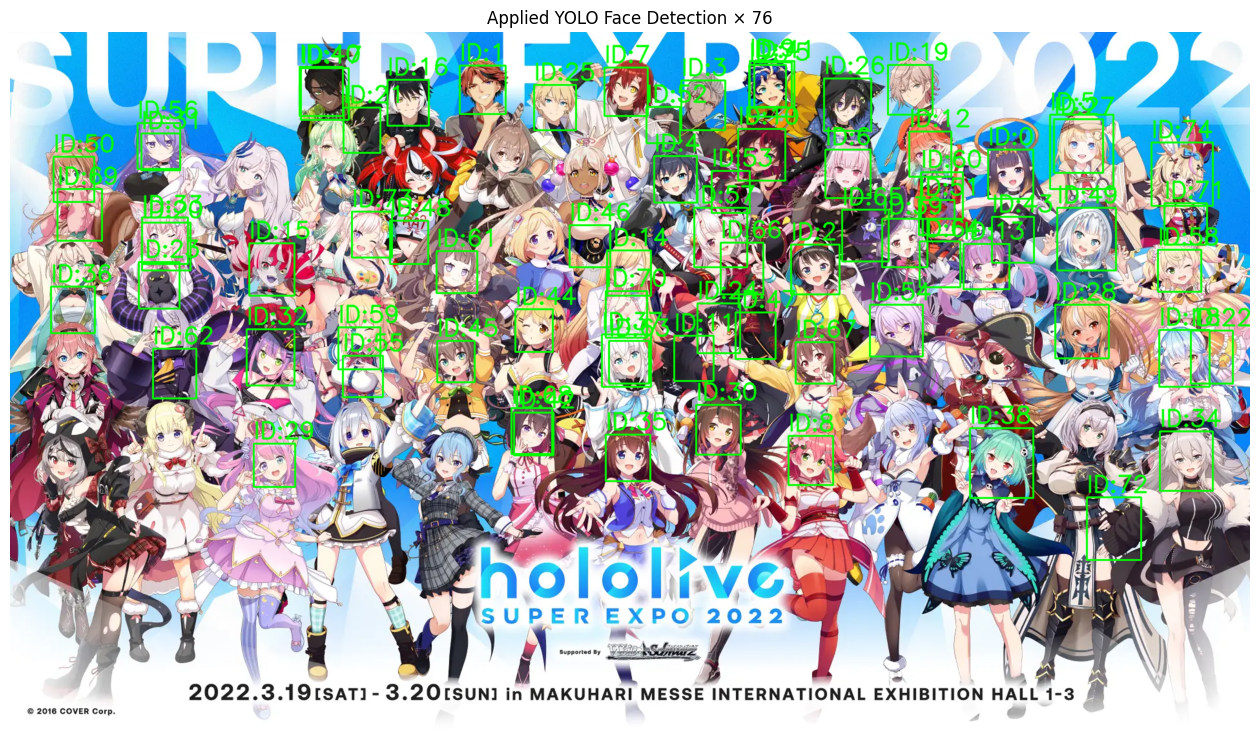

In [4]:
import cv2
import numpy as np
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

IMAGE_PATH = Path("hololive2.jpg")
MODEL_PATH = Path("yolov8m-face.pt")

CONF = 0.20          
IMG_SIZE = 1280
PAD_RATIO = 0.30     

def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    smooth = cv2.bilateralFilter(gray, 9, 75, 75)

    return cv2.cvtColor(smooth, cv2.COLOR_GRAY2BGR)

def main():
    raw = cv2.imread(str(IMAGE_PATH))
    if raw is None:
        raise FileNotFoundError("画像が読み込めません")

    h_img, w_img = raw.shape[:2]

    processed = preprocess(raw)

    model = YOLO(MODEL_PATH)
    result = model.predict(
        source=processed,
        conf=CONF,
        imgsz=IMG_SIZE,
        augment=True,
        verbose=False
    )[0]

    annotated = raw.copy()
    detections = []   

    for idx, box in enumerate(result.boxes.xyxy.cpu().numpy()):
        x1, y1, x2, y2 = map(int, box)
        w = x2 - x1
        h = y2 - y1

        pad = int(max(w, h) * PAD_RATIO)
        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)
        x2p = min(w_img, x2 + pad)
        y2p = min(h_img, y2 + pad)

        roi = raw[y1p:y2p, x1p:x2p]

        detections.append({
            "id": idx,
            "bbox": (x1p, y1p, x2p, y2p),
            "width": x2p - x1p,
            "height": y2p - y1p,
            "area_ratio": ((x2p - x1p) * (y2p - y1p)) / (w_img * h_img),
            "roi": roi
        })

        cv2.rectangle(annotated, (x1p, y1p), (x2p, y2p), (0,255,0), 2)
        cv2.putText(
            annotated,
            f"ID:{idx}",
            (x1p, y1p - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0,255,0),
            2,
            cv2.LINE_AA
        )

    faces_dir = Path("faces")
    faces_dir.mkdir(exist_ok=True)

    for d in detections:
        cv2.imwrite(
            str(faces_dir / f"face_{d['id']}.jpg"),
            d["roi"]
        )

    detections.sort(key=lambda x: x["area_ratio"], reverse=True)

    print(f"検出数: {len(detections)}")
    for d in detections[:5]:
        print(f"ID {d['id']} 面積比 {d['area_ratio']:.4f}")

    out = cv2.resize(
        annotated,
        (w_img * 2, h_img * 2),
        interpolation=cv2.INTER_CUBIC
    )

    cv2.imwrite("hololive_yolo_applied.jpg", out)

    plt.figure(figsize=(16, 16))
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Applied YOLO Face Detection × {len(detections)}")
    plt.show()

if __name__ == "__main__":
    main()


検出数: 24
ID 22 面積比 0.0085
ID 20 面積比 0.0060
ID 6 面積比 0.0057
ID 13 面積比 0.0056
ID 17 面積比 0.0053


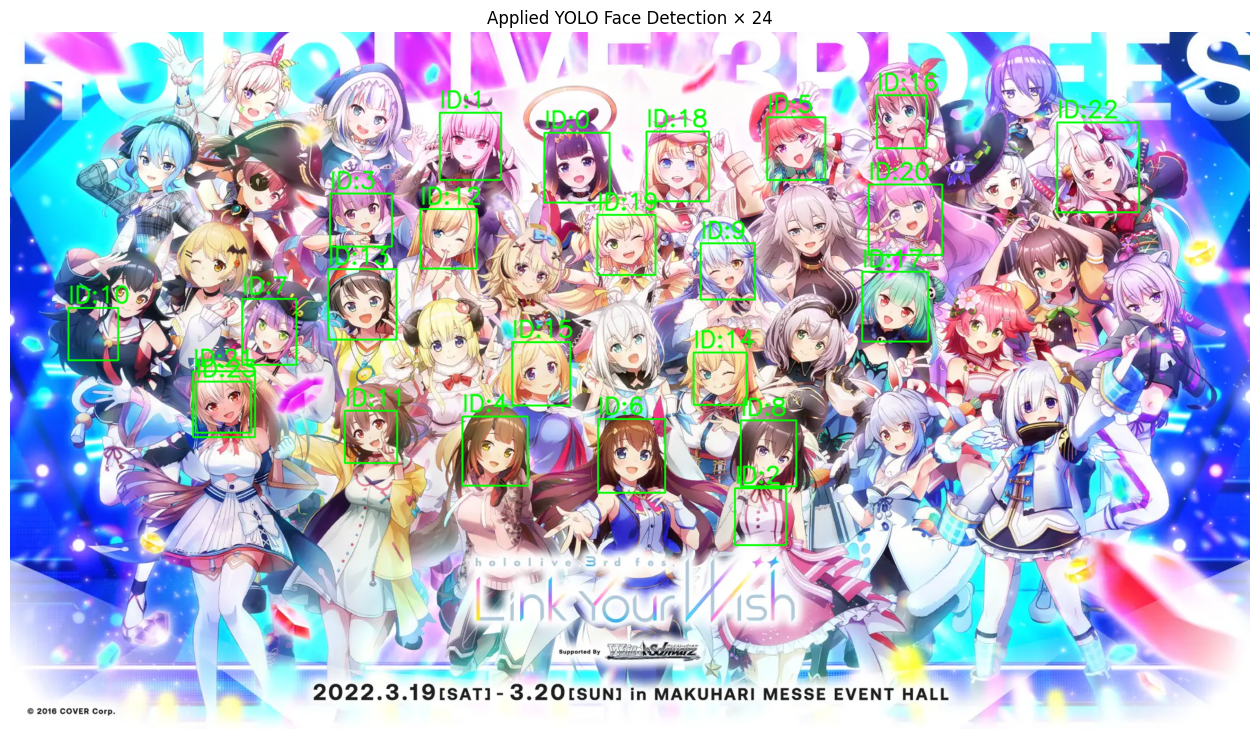

In [5]:
import cv2
import numpy as np
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt

IMAGE_PATH = Path("hololive.jpg")
MODEL_PATH = Path("yolov8m-face.pt")

CONF = 0.20          
IMG_SIZE = 1280
PAD_RATIO = 0.30     

def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    smooth = cv2.bilateralFilter(gray, 9, 75, 75)

    return cv2.cvtColor(smooth, cv2.COLOR_GRAY2BGR)

def main():
    raw = cv2.imread(str(IMAGE_PATH))
    if raw is None:
        raise FileNotFoundError("画像が読み込めません")

    h_img, w_img = raw.shape[:2]

    processed = preprocess(raw)

    model = YOLO(MODEL_PATH)
    result = model.predict(
        source=processed,
        conf=CONF,
        imgsz=IMG_SIZE,
        augment=True,
        verbose=False
    )[0]

    annotated = raw.copy()
    detections = []   

    for idx, box in enumerate(result.boxes.xyxy.cpu().numpy()):
        x1, y1, x2, y2 = map(int, box)
        w = x2 - x1
        h = y2 - y1

        pad = int(max(w, h) * PAD_RATIO)
        x1p = max(0, x1 - pad)
        y1p = max(0, y1 - pad)
        x2p = min(w_img, x2 + pad)
        y2p = min(h_img, y2 + pad)

        roi = raw[y1p:y2p, x1p:x2p]

        detections.append({
            "id": idx,
            "bbox": (x1p, y1p, x2p, y2p),
            "width": x2p - x1p,
            "height": y2p - y1p,
            "area_ratio": ((x2p - x1p) * (y2p - y1p)) / (w_img * h_img),
            "roi": roi
        })

        cv2.rectangle(annotated, (x1p, y1p), (x2p, y2p), (0,255,0), 2)
        cv2.putText(
            annotated,
            f"ID:{idx}",
            (x1p, y1p - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0,255,0),
            2,
            cv2.LINE_AA
        )

    faces_dir = Path("faces")
    faces_dir.mkdir(exist_ok=True)

    for d in detections:
        cv2.imwrite(
            str(faces_dir / f"face_{d['id']}.jpg"),
            d["roi"]
        )

    detections.sort(key=lambda x: x["area_ratio"], reverse=True)

    print(f"検出数: {len(detections)}")
    for d in detections[:5]:
        print(f"ID {d['id']} 面積比 {d['area_ratio']:.4f}")

    out = cv2.resize(
        annotated,
        (w_img * 2, h_img * 2),
        interpolation=cv2.INTER_CUBIC
    )

    cv2.imwrite("hololive2_yolo_applied.jpg", out)

    plt.figure(figsize=(16, 16))
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Applied YOLO Face Detection × {len(detections)}")
    plt.show()

if __name__ == "__main__":
    main()
